In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
#selecting the numerical values
glucose = df["Glucose"]

print("Mean Glucose:", glucose.mean())

Mean Glucose: 120.89453125


In [ ]:
#Bootstrap Samples
np.random.seed(42)

n = len(glucose)
bootstrap_means = []

for i in range(1000):
    sample = glucose.sample(n=n, replace=True)
    bootstrap_means.append(sample.mean())

print("Number of bootstrap samples:", len(bootstrap_means))

Number of bootstrap samples: 1000


In [ ]:
#Calculating Mean for every Bootstrap sample
print("First 10 Bootstrap Means:")
print(bootstrap_means[:10])

First 10 Bootstrap Means:
[np.float64(121.35286458333333), np.float64(122.08463541666667), np.float64(121.85677083333333), np.float64(121.45052083333333), np.float64(120.92708333333333), np.float64(119.99609375), np.float64(120.1328125), np.float64(120.26953125), np.float64(119.65625), np.float64(121.02213541666667)]


In [ ]:
#Bootstrap Confidence Interval
lower = np.percentile(bootstrap_means, 2.5)
upper = np.percentile(bootstrap_means, 97.5)

print("95% Bootstrap Confidence Interval")
print("Lower Limit:", lower)
print("Upper Limit:", upper)

95% Bootstrap Confidence Interval
Lower Limit: 118.77721354166667
Upper Limit: 123.01858723958334


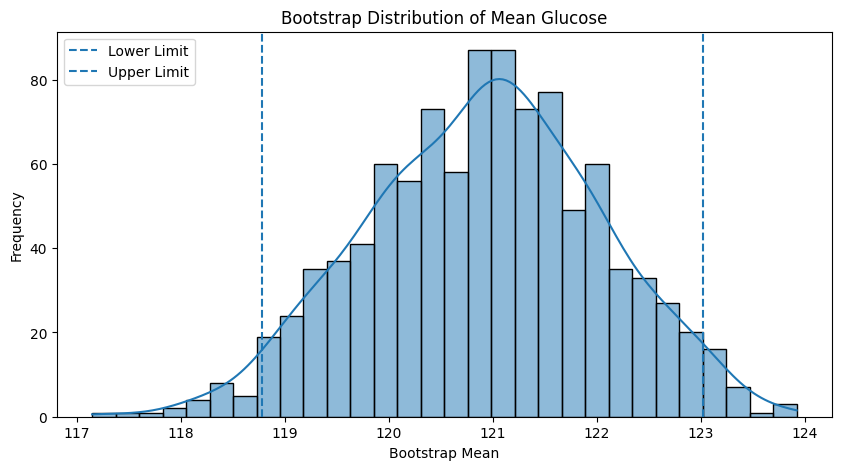

In [ ]:
#visulizing Bootstrap Distribution
plt.figure(figsize=(10, 5))

sns.histplot(bootstrap_means, bins=30, kde=True)

plt.axvline(lower, linestyle="--", label="Lower Limit")
plt.axvline(upper, linestyle="--", label="Upper Limit")

plt.title("Bootstrap Distribution of Mean Glucose")
plt.xlabel("Bootstrap Mean")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [ ]:
#Divide Data into groups
group0 = df[df["Outcome"] == 0]["Glucose"]
group1 = df[df["Outcome"] == 1]["Glucose"]

print("Non-diabetic patients:", len(group0))
print("Diabetic patients:", len(group1))

Non-diabetic patients: 500
Diabetic patients: 268


In [ ]:
#Calcultae Observed Difference Between Group Means
mean0 = group0.mean()
mean1 = group1.mean()

observed_difference = mean1 - mean0

print("Mean Glucose - Non-diabetic:", mean0)
print("Mean Glucose - Diabetic:", mean1)
print("Observed Difference:", observed_difference)

Mean Glucose - Non-diabetic: 109.98
Mean Glucose - Diabetic: 141.25746268656715
Observed Difference: 31.277462686567148


In [ ]:
# Randomly Permute Group Labels
np.random.seed(42)

combined = pd.concat([group0, group1]).reset_index(drop=True)
n0 = len(group0)
permutation_differences = []
for i in range(1000):
    shuffled = np.random.permutation(combined)
    new_group0 = shuffled[:n0]
    new_group1 = shuffled[n0:]
    difference = new_group1.mean() - new_group0.mean()
    permutation_differences.append(difference)

print("Number of permutations:", len(permutation_differences))

Number of permutations: 1000


In [ ]:

#Calculate Diffrence for every Permutation
print("First 10 Permutation Differences:")
print(permutation_differences[:10])

First 10 Permutation Differences:
[np.float64(4.013462686567166), np.float64(0.3454029850746281), np.float64(-0.8581791044776139), np.float64(1.7897014925373185), np.float64(-1.408388059701494), np.float64(2.752567164179112), np.float64(-1.2421791044776143), np.float64(2.9187761194029775), np.float64(-2.141999999999996), np.float64(0.2995522388059584)]


In [ ]:

#Compare Observed Difference with Permutation Distribution
permutation_differences = np.array(permutation_differences)

p_value = np.mean(
    np.abs(permutation_differences) >= abs(observed_difference)
)

print("Observed Difference:", observed_difference)
print("Permutation Test P-value:", p_value)

Observed Difference: 31.277462686567148
Permutation Test P-value: 0.0


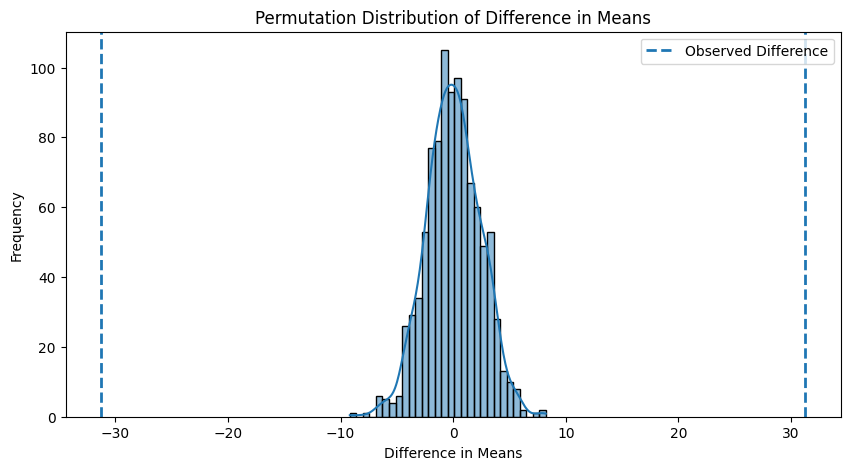

In [ ]:
#Visulize the Permutation Distribution
plt.figure(figsize=(10, 5))

sns.histplot(permutation_differences, bins=30, kde=True)

plt.axvline(
    observed_difference,
    linestyle="--",
    linewidth=2,
    label="Observed Difference"
)

plt.axvline(
    -observed_difference,
    linestyle="--",
    linewidth=2
)

plt.title("Permutation Distribution of Difference in Means")
plt.xlabel("Difference in Means")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [ ]:
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Reject the Null Hypothesis
